# 🚦 TomTom Traffic API

Agenda:
- What the API gives us
- What every piece of data means
- How we store data in the database

---
## Section 1 : What API Are We Using?

We are using this TomTom endpoint:
```
https://api.tomtom.com/traffic/services/4/flowSegmentData/absolute/10/json
```

**What does it do?**

You give it a location (latitude and longitude) and it gives you back **real-time traffic information** for the road near that location.

 Example:
- You send: `lat = 30.0444, lon = 31.2357` (Tahrir Square)
- TomTom finds the nearest road
- TomTom returns: how fast cars are moving, normal speed, travel time, etc.

> **Important:** The API does NOT give you traffic for the entire road network. It gives traffic for **ONE small piece of road** near the point you give it.

---
## Section 2 : What is a "Road Segment"?

### A road is made of many small pieces

Think of any road as a long line. That line is cut into small pieces. Each piece is called a **road segment**.
```
Salah Salem Road:
A -------- B -------- C -------- D
```

| Segment | From | To |
|---------|------|----|
| Segment 1 | A | B |
| Segment 2 | B | C |
| Segment 3 | C | D |

Each segment can have **different traffic**:

| Segment | Speed |
|---------|-------|
| A → B | 60 km/h 🟩 Fast |
| B → C | 20 km/h 🔴 Slow |
| C → D | 50 km/h 🟡 Moderate |

### What happens when you call the API?

1. You send one coordinate (lat, lon)
2. TomTom finds the **nearest road segment** to that coordinate
3. TomTom returns traffic info for **that one segment only**


---
## Section 3 : What Does the API Return (Features)?

API response:
```json
{
  "frc": "FRC3",
  "currentSpeed": 32,
  "freeFlowSpeed": 60,
  "currentTravelTime": 50,
  "freeFlowTravelTime": 25,
  "confidence": 0.95,
  "roadClosure": false,
  "coordinates": { ... }
}
```

### What does each field mean?

| Field | What It Means | Example |
|-------|--------------|---------|
| `frc` | Road type (highway, local road, etc.) | `FRC0` = Highway |
| `currentSpeed` | How fast cars are moving **right now** | `32 km/h` |
| `freeFlowSpeed` | Normal speed when there is **no traffic** | `60 km/h` |
| `currentTravelTime` | Time to pass this segment **right now** (seconds) | `50 sec` |
| `freeFlowTravelTime` | Time to pass with **no traffic** (seconds) | `25 sec` |
| `confidence` | How reliable this data is (0 to 1) | `0.95` = very reliable |
| `roadClosure` | Is the road blocked? | `false` = open |
| `coordinates` | GPS points that draw the road shape | list of lat/lon |

---

### What is FRC (Functional Road Class)?

FRC tells us what **type of road** the segment is. Higher number = smaller/less important road.

| FRC Value | Road Type |
|-----------|-----------|
| FRC0 | Motorway / Freeway (biggest roads) |
| FRC1 | Major road (national level) |
| FRC2 | Major city road |
| FRC3 | Secondary road |
| FRC4 | Local connecting road |
| FRC5 | Local road (high importance) |
| FRC6 | Local road |
| FRC7 | Minor local road / dead-end |
| FRC8 | Paths, bicycle lanes, stairs, pedestrian areas |

---
## Section 4 : Why Does the API Return Many Coordinates?

When you get a response from the API, you will see something like this:
```json
"coordinates": {
  "coordinate": [
    {"latitude": 30.01227, "longitude": 31.20747},
    {"latitude": 30.01230, "longitude": 31.20755},
    {"latitude": 30.01234, "longitude": 31.20760}
  ]
}
```

**Does this mean multiple roads?**

**No** These points all belong to the **same road segment**.

They are just used to **draw the shape** of the road on a map.

### Do all these points share the same traffic data?

**Yes** All points belong to the same segment, so they all have the same speed, travel time, etc.

| Point | Speed |
|-------|-------|
| Point 1 | 32 km/h |
| Point 2 | 32 km/h |
| Point 3 | 32 km/h |

Traffic only changes when you move to a **different segment**.

---
## Section 5 : Understanding Congestion Ratio

Will be used for the **AI model**.

### Formula:
```
congestion_ratio = currentSpeed / freeFlowSpeed
```

### Example:
```
currentSpeed  = 32 km/h
freeFlowSpeed = 60 km/h

congestion_ratio = 32 / 60 = 0.53
```

### What does the ratio mean?

| Ratio | Traffic Condition | Color on Map |
|-------|------------------|--------------|
| > 0.8 | 🟢 Free flow | Green |
| 0.5 – 0.8 | 🟡 Moderate traffic | Yellow |
| 0.3 – 0.5 | 🟠 Heavy traffic | Orange |
| < 0.3 | 🔴 Severe congestion | Red |

> A ratio of **1.0** means cars are moving at normal speed (no traffic).
> A ratio of **0.2** means cars are moving at only 20% of normal speed (very bad traffic)

---
## Section 6 : Data Quality Checks (Suspicious Data)

We must check for these problems in the DB:

| Problem | What It Means | How to Detect |
|---------|--------------|---------------|
| Speed = 0 but road is NOT closed | Possible accident or sensor error | `currentSpeed == 0 and roadClosure == False` |
| Current speed > free flow speed | Impossible in normal traffic (likely an error) | `currentSpeed > freeFlowSpeed` |
| Very low confidence (< 0.5) | Data is unreliable | `confidence < 0.5` |
| Sudden speed drop (40+ km/h in 1 step) | Could be an accident or bad reading | Compare speed between timestamps |

---
## Section 7 :How to verify our data is correct?

Open **Google Maps** → Search the lat/lon → Click **Layers → Traffic**

Compare what Google shows vs what our API returned.

# 🚦 Traffic Analytics EDA
**What this notebook does:**

Collects live traffic data across multiple locations over time & Runs a full Exploratory Data Analysis (EDA)

---
### Agenda
1. Install & Import Libraries  
2. Configuration : Add Your API Key & Locations  
3. Fetch Data from TomTom API  
4. Collect Data Over Multiple Rounds
5. First Look at the Data  
6. Data Quality Check  
7. Speed Analysis  
8. Congestion Analysis  
9. Time Patterns  
10. Location Comparison  
11. Road Closure & Confidence Analysis  
12. Correlation & Feature Relationships  
13. Key Findings


## 1. Install & Import Libraries

In [ ]:
!pip install -q folium missingno

In [ ]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import folium
import missingno as msno
import time
import json
from datetime import datetime, timezone
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')


plt.rcParams['figure.figsize']   = (13, 5)
plt.rcParams['axes.spines.top']  = False
plt.rcParams['axes.spines.right']= False
plt.rcParams['font.size']        = 11
sns.set_palette('husl')

print('All libraries imported successfully!')

All libraries imported successfully!


## 2. Configuration — Add Your API Key & Locations

> **Important:** Replace `YOUR_TOMTOM_API_KEY_HERE` with your key.
>
> You can add as many locations as you want just add more dicts to the list.
> Coordinates are `(latitude, longitude)`  you can get them from Google Maps.

In [ ]:

API_KEY = 'YOUR_TOMTOM_API_KEY_HERE'   # paste your key here

LOCATIONS = [
    {'name': 'Tahrir Square',         'lat': 30.0444, 'lon': 31.2357},
    {'name': 'Nasr City Ring Road',   'lat': 30.0626, 'lon': 31.3417},
    {'name': 'October Bridge',        'lat': 30.0603, 'lon': 31.2446},
    {'name': 'El-Rawda St',           'lat': 30.015822,'lon':31.223920},
    {'name': 'Maadi Corniche',        'lat': 29.9602, 'lon': 31.2569},
    {'name': 'El-Gomhoreya St',       'lat': 30.0499, 'lon': 31.2466},
    {'name': 'El-Gaish St',           'lat': 30.0523, 'lon': 31.2542},
    {'name': 'Salah Salem Road',      'lat': 30.0396, 'lon': 31.2657},
    {'name': 'Ramses St',             'lat': 30.052613, 'lon': 31.237925},
    {'name': 'Talaat Harb St',        'lat': 30.0506, 'lon': 31.2404},
    {'name': 'El Haram St',           'lat': 30.015433, 'lon': 31.214553},
    {'name': 'Nile Corniche',         'lat': 30.047107, 'lon': 31.231616},
    {'name': '26th of July Corridor', 'lat': 30.063321, 'lon': 31.167581},
    {'name': 'Gamal Abd El-Nasser Rd','lat': 30.051973, 'lon': 31.216775},

]
# How many rounds of data to collect:
# Each round calls the API once per location.
# 10 rounds × 14 locations = 140 API calls.
ROUNDS        = 10
SLEEP_SECONDS = 60   # wait between rounds (API updates every 60s)

# API settings
BASE_URL  = 'https://api.tomtom.com/traffic/services/4/flowSegmentData'
STYLE     = 'absolute'
ZOOM      = 10
FORMAT    = 'json'
UNIT      = 'kmph'

print(f'   Config ready')
print(f'   Locations : {len(LOCATIONS)}')
print(f'   Rounds    : {ROUNDS}')
print(f'   Total API calls planned: {len(LOCATIONS) * ROUNDS}')
print(f'   Estimated time: ~{ROUNDS * SLEEP_SECONDS // 60} minutes')

   Config ready
   Locations : 14
   Rounds    : 10
   Total API calls planned: 140
   Estimated time: ~10 minutes


## 3. Fetch Data from TomTom API

test the API with a **single call** to make sure API key is valid

In [ ]:
def fetch_traffic(lat, lon, api_key=API_KEY):
    """
    Call TomTom Flow Segment Data API for one coordinate.
    Returns a flat dict ready for a DataFrame row, or None on failure.
    """
    url = f'{BASE_URL}/{STYLE}/{ZOOM}/{FORMAT}'
    params = {
        'key'   : api_key,
        'point' : f'{lat},{lon}',
        'unit'  : UNIT,
    }
    try:
        response = requests.get(url, params=params, timeout=10)

        # Handle common HTTP errors
        if response.status_code == 403:
            print('HTTP 403 — Invalid API key or quota exceeded.')
            return None
        if response.status_code == 429:
            print('HTTP 429 — Rate limit hit. Sleeping 10 seconds...')
            time.sleep(10)
            return None
        if response.status_code != 200:
            print(f'HTTP {response.status_code} for ({lat},{lon})')
            return None

        data = response.json()
        seg  = data.get('flowSegmentData', {})

        return {
            'request_time'          : datetime.now(timezone.utc).isoformat(),
            'requested_lat'         : lat,
            'requested_lon'         : lon,
            'frc'                   : seg.get('frc'),
            'current_speed'         : seg.get('currentSpeed'),
            'free_flow_speed'       : seg.get('freeFlowSpeed'),
            'current_travel_time'   : seg.get('currentTravelTime'),
            'free_flow_travel_time' : seg.get('freeFlowTravelTime'),
            'confidence'            : seg.get('confidence'),
            'road_closure'          : seg.get('roadClosure', False),
        }

    except requests.exceptions.ConnectionError:
        print(f' Connection error for ({lat},{lon}). Check your internet.')
        return None
    except requests.exceptions.Timeout:
        print(f'  Timeout for ({lat},{lon}). Skipping.')
        return None
    except Exception as e:
        print(f' Unexpected error: {e}')
        return None


# test with one location
print('Testing API connection')
test_loc    = LOCATIONS[-6]
test_result = fetch_traffic(test_loc['lat'], test_loc['lon'])

if test_result:
    print(f'\n API is working! Sample response for "{test_loc["name"]}":')
    for k, v in test_result.items():
        print(f'   {k:<28} {v}')
else:
    print('\n API test failed. Check your API_KEY in Cell 2.')

Testing API connection

 API is working! Sample response for "Ramses St":
   request_time                 2026-03-24T12:15:25.326692+00:00
   requested_lat                30.052613
   requested_lon                31.237925
   frc                          FRC3
   current_speed                24
   free_flow_speed              30
   current_travel_time          330
   free_flow_travel_time        264
   confidence                   1
   road_closure                 False


## 4. Collect Data Over Multiple Rounds

This cell loops through all your locations repeatedly and builds a real dataset.

In [ ]:
all_records = []
total_calls = 0

print(f' Starting data collection — {ROUNDS} rounds × {len(LOCATIONS)} locations')
print('=' * 60)

for round_num in range(1, ROUNDS + 1):
    round_start = datetime.now()
    round_records = []

    for loc in LOCATIONS:
        record = fetch_traffic(loc['lat'], loc['lon'])
        if record:
            record['location_name'] = loc['name']
            round_records.append(record)
        total_calls += 1
        time.sleep(0.3)

    all_records.extend(round_records)

    # Show a mini summary for this round
    speeds = [r['current_speed'] for r in round_records if r.get('current_speed')]
    avg_spd = sum(speeds) / len(speeds) if speeds else 0
    print(f'  Round {round_num:>2}/{ROUNDS} — {len(round_records)} locations fetched | '
          f'avg speed: {avg_spd:.1f} km/h | '
          f'time: {round_start.strftime("%H:%M:%S")}')

    # Wait between rounds but skip wait on last round
    if round_num < ROUNDS:
        print(f'         Waiting {SLEEP_SECONDS}s before next round')
        time.sleep(SLEEP_SECONDS)

print('=' * 60)
print(f'Done Collected {len(all_records)} records in {total_calls} API calls.')

# Build DataFrame
df = pd.DataFrame(all_records)
df['request_time'] = pd.to_datetime(df['request_time'], utc=True)

# Save raw data
df.to_csv('tomtom_raw_data.csv', index=False)
print(f'Raw data saved to tomtom_raw_data.csv')

 Starting data collection — 10 rounds × 14 locations
  Round  1/10 — 14 locations fetched | avg speed: 32.6 km/h | time: 11:42:28
         Waiting 60s before next round
  Round  2/10 — 14 locations fetched | avg speed: 32.6 km/h | time: 11:43:40
         Waiting 60s before next round
  Round  3/10 — 14 locations fetched | avg speed: 32.9 km/h | time: 11:44:52
         Waiting 60s before next round
  Round  4/10 — 14 locations fetched | avg speed: 32.1 km/h | time: 11:46:04
         Waiting 60s before next round
  Round  5/10 — 14 locations fetched | avg speed: 32.5 km/h | time: 11:47:16
         Waiting 60s before next round
  Round  6/10 — 14 locations fetched | avg speed: 32.9 km/h | time: 11:48:27
         Waiting 60s before next round
  Round  7/10 — 14 locations fetched | avg speed: 32.6 km/h | time: 11:49:39
         Waiting 60s before next round
  Round  8/10 — 14 locations fetched | avg speed: 32.9 km/h | time: 11:50:51
         Waiting 60s before next round
  Round  9/10 — 14 

## 5. First Look at the Data

In [ ]:
print('═' * 55)
print(f'  Shape: {df.shape[0]:,} rows  ×  {df.shape[1]} columns')
print('═' * 55)
print('\nColumn types:')
print(df.dtypes.to_string())
print('\nFirst 5 rows:')
df.head()

═══════════════════════════════════════════════════════
  Shape: 140 rows  ×  11 columns
═══════════════════════════════════════════════════════

Column types:
request_time             datetime64[ns, UTC]
requested_lat                        float64
requested_lon                        float64
frc                                   object
current_speed                          int64
free_flow_speed                        int64
current_travel_time                    int64
free_flow_travel_time                  int64
confidence                           float64
road_closure                            bool
location_name                         object

First 5 rows:


,request_time,requested_lat,requested_lon,frc,current_speed,free_flow_speed,current_travel_time,free_flow_travel_time,confidence,road_closure,location_name
0,2026-03-24 11:42:29.391733+00:00,30.044400,31.23570,FRC4,20,20,66,66,1.000000,False,Tahrir Square
1,2026-03-24 11:42:30.212942+00:00,30.062600,31.34170,FRC1,51,51,409,409,1.000000,False,Nasr City Ring Road
2,2026-03-24 11:42:31.113437+00:00,30.060300,31.24460,FRC3,26,26,269,269,1.000000,False,October Bridge
3,2026-03-24 11:42:31.961775+00:00,30.015822,31.22392,FRC1,23,23,169,169,0.807339,True,El-Rawda St
4,2026-03-24 11:42:32.774469+00:00,29.960200,31.25690,FRC4,33,33,81,81,1.000000,False,Maadi Corniche


In [ ]:
print('Basic statistics:')
df.describe(include='all').round(3)

Basic statistics:


,request_time,requested_lat,requested_lon,frc,current_speed,free_flow_speed,current_travel_time,free_flow_travel_time,confidence,road_closure,location_name
count,140,140.000,140.000,140,140.000,140.000,140.000,140.000,140.000,140,140
unique,NaN,NaN,NaN,5,NaN,NaN,NaN,NaN,NaN,2,14
top,NaN,NaN,NaN,FRC4,NaN,NaN,NaN,NaN,NaN,False,Tahrir Square
freq,NaN,NaN,NaN,50,NaN,NaN,NaN,NaN,NaN,110,10
mean,2026-03-24 11:47:57.915321600+00:00,30.040,31.241,NaN,32.657,33.557,324.479,315.557,0.963,NaN,NaN
min,2026-03-24 11:42:29.391733+00:00,29.960,31.168,NaN,17.000,17.000,66.000,66.000,0.704,NaN,NaN
25%,2026-03-24 11:44:58.669681152+00:00,30.040,31.224,NaN,20.000,20.000,107.000,101.000,1.000,NaN,NaN
50%,2026-03-24 11:47:57.894529024+00:00,30.050,31.239,NaN,26.000,28.500,220.000,220.000,1.000,NaN,NaN
75%,2026-03-24 11:50:57.180922112+00:00,30.053,31.254,NaN,39.000,39.000,409.000,409.000,1.000,NaN,NaN
max,2026-03-24 11:53:26.235693+00:00,30.063,31.342,NaN,78.000,78.000,1259.000,1259.000,1.000,NaN,NaN


In [ ]:
#Add derived columns used throughout the analysis
df['hour']             = df['request_time'].dt.hour
df['minute']           = df['request_time'].dt.minute
df['day_of_week']      = df['request_time'].dt.day_name()
df['date']             = df['request_time'].dt.date
df['congestion_ratio'] = (df['current_speed'] / df['free_flow_speed']).round(4)
df['speed_drop_pct']   = ((df['free_flow_speed'] - df['current_speed'])
                          / df['free_flow_speed'] * 100).round(2)
df['delay_seconds']    = df['current_travel_time'] - df['free_flow_travel_time']
df['is_rush_hour']     = df['hour'].apply(
    lambda h: 'Rush hour' if (7 <= h <= 9 or 16 <= h <= 19) else 'Off-peak')

def congestion_label(r):
    if pd.isna(r):  return 'Unknown'
    if r >= 0.80:   return 'Free Flow'
    if r >= 0.60:   return 'Light'
    if r >= 0.40:   return 'Moderate'
    if r >= 0.20:   return 'Heavy'
    return 'Severe'

df['congestion_level'] = df['congestion_ratio'].apply(congestion_label)

print('Derived columns created:')
new_cols = ['hour','minute','day_of_week','date','congestion_ratio',
            'speed_drop_pct','delay_seconds','is_rush_hour','congestion_level']
print('  ', ', '.join(new_cols))

Derived columns created:
   hour, minute, day_of_week, date, congestion_ratio, speed_drop_pct, delay_seconds, is_rush_hour, congestion_level


## 6. Data Quality Check

 No missing values


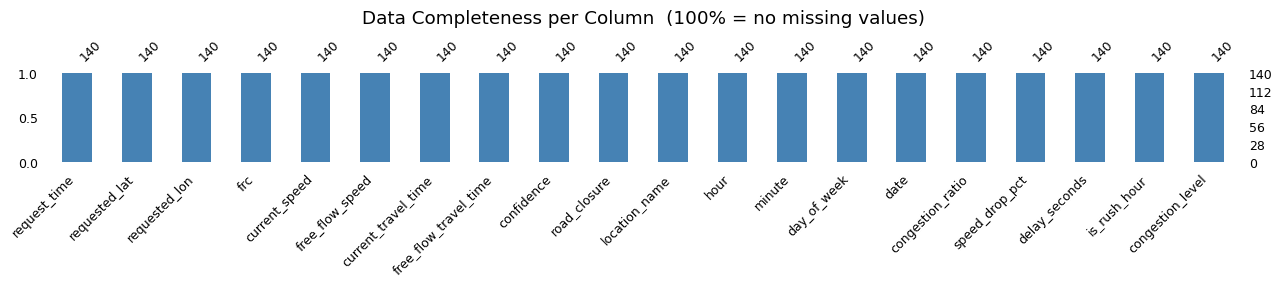

In [ ]:
# Missing values
missing    = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
quality_df = pd.DataFrame({'Missing #': missing, 'Missing %': missing_pct})
quality_df = quality_df[quality_df['Missing #'] > 0]

if quality_df.empty:
    print(' No missing values')
else:
    print('  Missing values found:')
    print(quality_df.to_string())

# Visual completeness chart
fig, ax = plt.subplots(figsize=(13, 3))
msno.bar(df, ax=ax, color='steelblue', fontsize=9)
ax.set_title('Data Completeness per Column  (100% = no missing values)', pad=10)
plt.tight_layout()
plt.show()

In [ ]:
checks = {
    'Duplicate rows'                  : df.duplicated().sum(),
    'Negative current_speed'          : (df['current_speed'] < 0).sum(),
    'Speed > 150 km/h (suspicious)'   : (df['current_speed'] > 150).sum(),
    'Confidence out of [0,1]'         : ((df['confidence'] < 0) | (df['confidence'] > 1)).sum(),
    'congestion_ratio > 1 (odd)'      : (df['congestion_ratio'] > 1).sum(),
    'Road closures detected'          : df['road_closure'].sum(),
}
print('Sanity Checks:')
for k, v in checks.items():
    flag = '⚠️ ' if v > 0 and 'closures' not in k else '✅'
    print(f'  {flag} {k:<40} {v}')

print(f'\n  Time range: {df.request_time.min()} → {df.request_time.max()}')
print(f'  Unique locations : {df.location_name.nunique()}')
print(f'  Unique FRC values: {sorted(df.frc.dropna().unique())}')

Sanity Checks:
  ✅ Duplicate rows                           0
  ✅ Negative current_speed                   0
  ✅ Speed > 150 km/h (suspicious)            0
  ✅ Confidence out of [0,1]                  0
  ✅ congestion_ratio > 1 (odd)               0
  ✅ Road closures detected                   30

  Time range: 2026-03-24 11:42:29.391733+00:00 → 2026-03-24 11:53:26.235693+00:00
  Unique locations : 14
  Unique FRC values: ['FRC0', 'FRC1', 'FRC2', 'FRC3', 'FRC4']


In [ ]:
# What does each FRC value mean?
frc_labels = {
    'FRC0': 'Motorway / Freeway',
    'FRC1': 'Major Road',
    'FRC2': 'Other Major Road',
    'FRC3': 'Secondary Road',
    'FRC4': 'Local Road',
    'FRC5': 'Local Road (minor)',
    'FRC6': 'Local Road (very minor)',
}
df['road_type'] = df['frc'].map(frc_labels).fillna('Unknown')

print('FRC breakdown in your data:')
frc_counts = df.groupby(['frc','road_type']).size().reset_index(name='count')
frc_counts['pct'] = (frc_counts['count'] / len(df) * 100).round(1)
print(frc_counts.to_string(index=False))

FRC breakdown in your data:
 frc          road_type  count  pct
FRC0 Motorway / Freeway     10  7.1
FRC1         Major Road     40 28.6
FRC2   Other Major Road     20 14.3
FRC3     Secondary Road     20 14.3
FRC4         Local Road     50 35.7


## 7. Speed Analysis

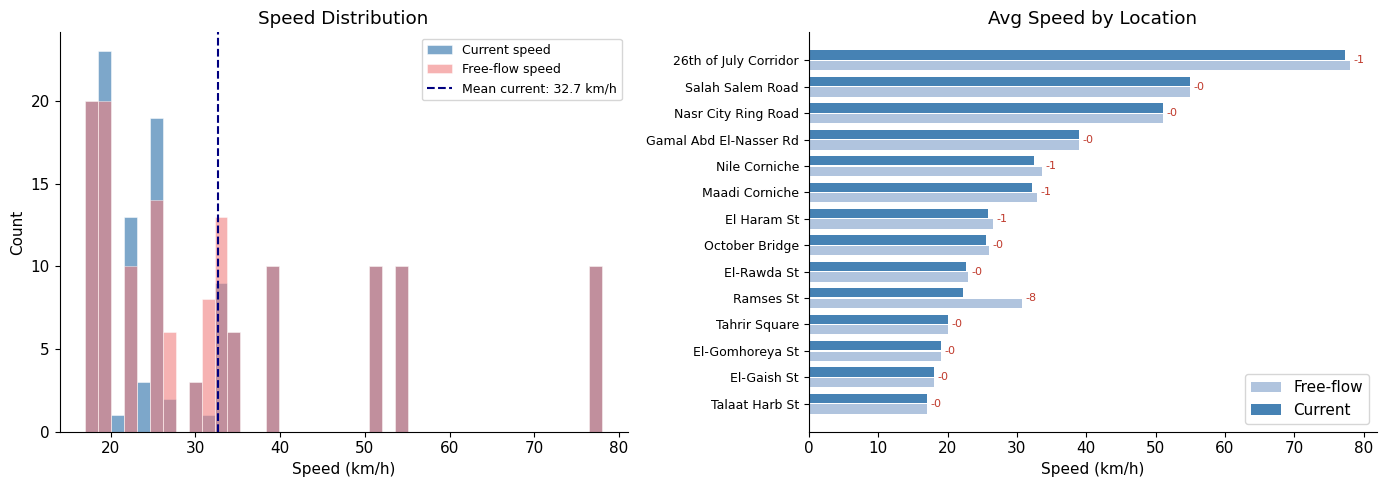

Current speed statistics:
count    140.00
mean      32.66
std       16.96
min       17.00
25%       20.00
50%       26.00
75%       39.00
max       78.00

Average speed gap (free-flow minus current): 0.9 km/h


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of current speed vs free-flow speed
df['current_speed'].dropna().plot.hist(
    bins=40, ax=axes[0], color='steelblue', alpha=0.7,
    edgecolor='white', linewidth=0.5, label='Current speed')
df['free_flow_speed'].dropna().plot.hist(
    bins=40, ax=axes[0], color='lightcoral', alpha=0.6,
    edgecolor='white', linewidth=0.5, label='Free-flow speed')
axes[0].axvline(df['current_speed'].mean(), color='navy',
                linestyle='--', linewidth=1.5,
                label=f'Mean current: {df["current_speed"].mean():.1f} km/h')
axes[0].set_title('Speed Distribution')
axes[0].set_xlabel('Speed (km/h)')
axes[0].set_ylabel('Count')
axes[0].legend(fontsize=9)

# Average speeds per location
loc_speeds = df.groupby('location_name')[['current_speed','free_flow_speed']].mean().round(1)
loc_speeds = loc_speeds.sort_values('current_speed')
x = np.arange(len(loc_speeds))
axes[1].barh(x - 0.2, loc_speeds['free_flow_speed'], 0.35,
             label='Free-flow', color='lightsteelblue')
axes[1].barh(x + 0.2, loc_speeds['current_speed'], 0.35,
             label='Current',   color='steelblue')
axes[1].set_yticks(x)
axes[1].set_yticklabels(loc_speeds.index, fontsize=9)
axes[1].set_title('Avg Speed by Location')
axes[1].set_xlabel('Speed (km/h)')
axes[1].legend()

# Annotate difference
for i, (cur, ff) in enumerate(zip(loc_speeds['current_speed'], loc_speeds['free_flow_speed'])):
    gap = ff - cur
    axes[1].text(max(cur, ff) + 0.5, i, f'-{gap:.0f}', va='center',
                 fontsize=8, color='#c0392b')

plt.tight_layout()
plt.show()

print('Current speed statistics:')
print(df['current_speed'].describe().round(2).to_string())
print(f'\nAverage speed gap (free-flow minus current): {(df["free_flow_speed"] - df["current_speed"]).mean():.1f} km/h')

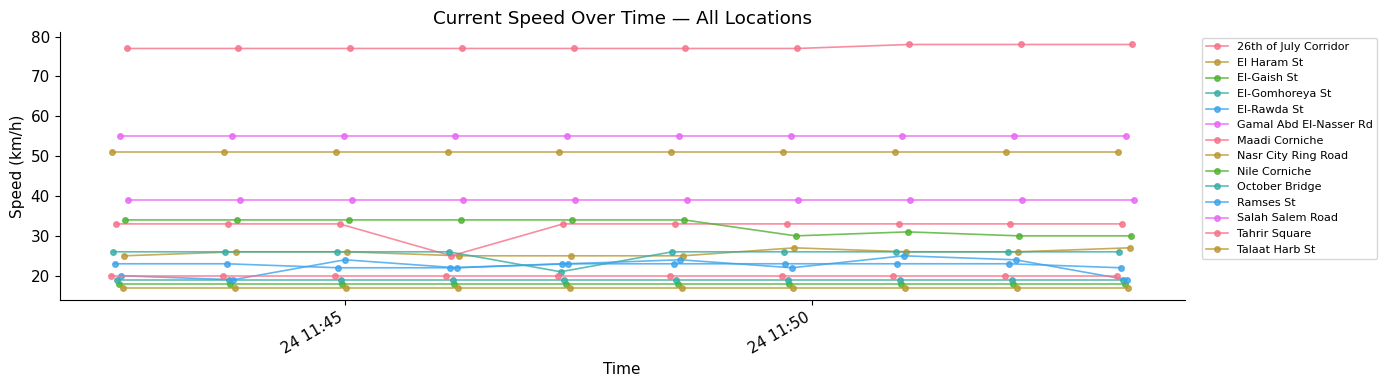

In [ ]:
'''
Purpose:

Observe how traffic changes over time.
'''
# Speed over time (timeline)
fig, ax = plt.subplots(figsize=(14, 4))

for loc_name, grp in df.groupby('location_name'):
    grp_sorted = grp.sort_values('request_time')
    ax.plot(grp_sorted['request_time'], grp_sorted['current_speed'],
            marker='o', markersize=4, linewidth=1.2, label=loc_name, alpha=0.8)

ax.set_title('Current Speed Over Time — All Locations')
ax.set_xlabel('Time')
ax.set_ylabel('Speed (km/h)')
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 8. Congestion Analysis
Purpose:
Show how often each traffic level occurs.

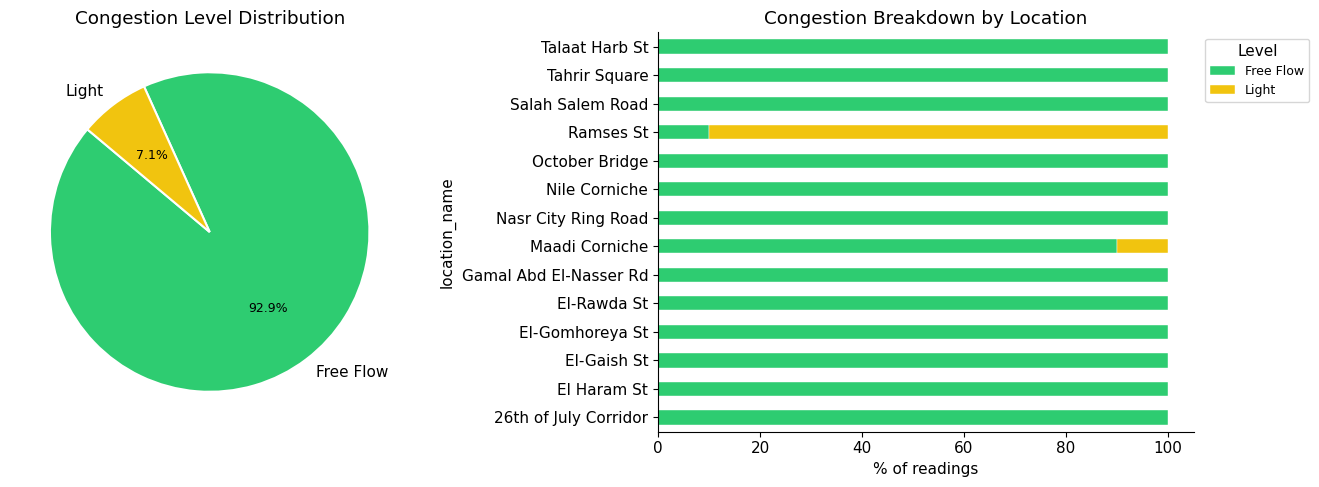

Congestion ratio statistics:
count    140.000
mean       0.971
std        0.077
min        0.613
25%        1.000
50%        1.000
75%        1.000
max        1.000


In [ ]:
level_order = ['Free Flow', 'Light', 'Moderate', 'Heavy', 'Severe', 'Unknown']
level_colors = {
    'Free Flow': '#2ecc71', 'Light': '#f1c40f', 'Moderate': '#e67e22',
    'Heavy': '#e74c3c',     'Severe': '#8e44ad', 'Unknown': '#95a5a6'
}

counts = df['congestion_level'].value_counts().reindex(level_order).dropna()
colors = [level_colors[l] for l in counts.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Pie chart
wedges, texts, autotexts = axes[0].pie(
    counts, labels=counts.index, colors=colors,
    autopct='%1.1f%%', startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
for t in autotexts: t.set_fontsize(9)
axes[0].set_title('Congestion Level Distribution')

# Stacked bar by location
loc_cong = (df.groupby(['location_name', 'congestion_level'])
              .size().unstack(fill_value=0))
present_levels = [l for l in level_order if l in loc_cong.columns]
loc_cong_pct = loc_cong[present_levels].div(loc_cong.sum(axis=1), axis=0) * 100
loc_cong_pct.plot(
    kind='barh', stacked=True, ax=axes[1],
    color=[level_colors[l] for l in present_levels],
    edgecolor='white', linewidth=0.3)
axes[1].set_title('Congestion Breakdown by Location')
axes[1].set_xlabel('% of readings')
axes[1].legend(title='Level', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

print('Congestion ratio statistics:')
print(df['congestion_ratio'].describe().round(3).to_string())

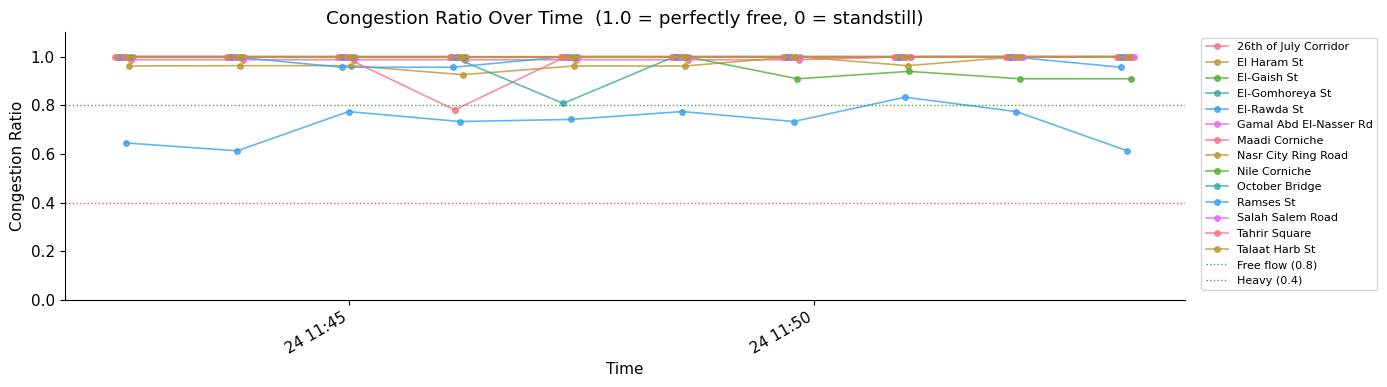

In [ ]:
# Congestion ratio over time
fig, ax = plt.subplots(figsize=(14, 4))

for loc_name, grp in df.groupby('location_name'):
    grp_sorted = grp.sort_values('request_time')
    ax.plot(grp_sorted['request_time'], grp_sorted['congestion_ratio'],
            marker='o', markersize=4, linewidth=1.2, label=loc_name, alpha=0.8)

ax.axhline(0.8, color='green', linestyle=':', linewidth=1, alpha=0.7, label='Free flow (0.8)')
ax.axhline(0.4, color='red',   linestyle=':', linewidth=1, alpha=0.7, label='Heavy (0.4)')
ax.set_title('Congestion Ratio Over Time  (1.0 = perfectly free, 0 = standstill)')
ax.set_xlabel('Time')
ax.set_ylabel('Congestion Ratio')
ax.set_ylim(0, 1.1)
ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1), loc='upper left')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

## 9. Time Patterns
*(More meaningful with 10+ rounds spanning different hours)*

In [ ]:
unique_hours = df['hour'].nunique()
print(f'Unique hours in dataset: {sorted(df["hour"].unique())}')

if unique_hours >= 3:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Average speed by hour
    hourly = df.groupby('hour')['current_speed'].mean()
    rush_hours = [h for h in hourly.index if (7 <= h <= 9 or 16 <= h <= 19)]
    bar_colors = ['#e74c3c' if h in rush_hours else 'steelblue' for h in hourly.index]
    axes[0].bar(hourly.index, hourly.values, color=bar_colors, edgecolor='white')
    axes[0].set_title('Average Speed by Hour')
    axes[0].set_xlabel('Hour of day')
    axes[0].set_ylabel('Avg speed (km/h)')
    axes[0].set_xticks(range(0, 24))
    axes[0].legend(handles=[
        mpatches.Patch(color='#e74c3c', label='Rush hours (7-9, 16-19)'),
        mpatches.Patch(color='steelblue', label='Other hours')
    ], fontsize=9)

    # Congestion ratio by hour (scatter)
    for loc, grp in df.groupby('location_name'):
        axes[1].scatter(grp['hour'], grp['congestion_ratio'],
                        alpha=0.5, s=30, label=loc)
    axes[1].set_title('Congestion Ratio by Hour  (each dot = 1 reading)')
    axes[1].set_xlabel('Hour of day')
    axes[1].set_ylabel('Congestion Ratio')
    axes[1].set_ylim(0, 1.1)
    axes[1].legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left')

    plt.tight_layout()
    plt.show()
else:
    print('    Not enough hour variation yet for a time-pattern chart.')
    print('   Collect more rounds across different hours for richer time analysis.')

Unique hours in dataset: [np.int32(11)]
    Not enough hour variation yet for a time-pattern chart.
   Collect more rounds across different hours for richer time analysis.


In [ ]:
# Rush hour vs off-peak comparison
rush_df    = df[df['is_rush_hour'] == 'Rush hour']
offpeak_df = df[df['is_rush_hour'] == 'Off-peak']

print('Rush Hour vs Off-Peak comparison:')
print(f'{"Metric":<30} {"Rush Hour":>12} {"Off-Peak":>12} {"Difference":>12}')
print('-' * 70)
metrics = [
    ('Avg current speed (km/h)', 'current_speed', 'mean'),
    ('Avg congestion ratio',     'congestion_ratio', 'mean'),
    ('Avg delay (seconds)',      'delay_seconds', 'mean'),
    ('Road closures',            'road_closure', 'sum'),
]
for label, col, func in metrics:
    rush_val    = getattr(rush_df[col].dropna(), func)()
    offpeak_val = getattr(offpeak_df[col].dropna(), func)()
    diff = offpeak_val - rush_val
    print(f'{label:<30} {rush_val:>12.2f} {offpeak_val:>12.2f} {diff:>+12.2f}')

print(f'\n  Rush hour readings  : {len(rush_df)}')
print(f'  Off-peak readings   : {len(offpeak_df)}')

Rush Hour vs Off-Peak comparison:
Metric                            Rush Hour     Off-Peak   Difference
----------------------------------------------------------------------
Avg current speed (km/h)                nan        32.66         +nan
Avg congestion ratio                    nan         0.97         +nan
Avg delay (seconds)                     nan         8.92         +nan
Road closures                          0.00        30.00       +30.00

  Rush hour readings  : 0
  Off-peak readings   : 140


## 10. Location Comparison

In [ ]:
# Detailed stats per location
loc_summary = df.groupby('location_name').agg(
    readings       = ('current_speed', 'count'),
    avg_speed      = ('current_speed', 'mean'),
    min_speed      = ('current_speed', 'min'),
    max_speed      = ('current_speed', 'max'),
    std_speed      = ('current_speed', 'std'),
    avg_congestion = ('congestion_ratio', 'mean'),
    avg_delay_s    = ('delay_seconds', 'mean'),
    road_closures  = ('road_closure', 'sum'),
    avg_confidence = ('confidence', 'mean'),
).round(2)

print('Location Summary (sorted by worst congestion first):')
loc_summary.sort_values('avg_congestion')

Location Summary (sorted by worst congestion first):


,readings,avg_speed,min_speed,max_speed,std_speed,avg_congestion,avg_delay_s,road_closures,avg_confidence
location_name,,,,,,,,,
Ramses St,10,22.2,19,25,2.20,0.72,102.1,0,1.00
El Haram St,10,25.8,25,27,0.79,0.97,3.2,10,0.75
Nile Corniche,10,32.5,30,34,1.96,0.97,3.6,0,1.00
Maadi Corniche,10,32.2,25,33,2.53,0.98,2.3,0,1.00
October Bridge,10,25.5,21,26,1.58,0.98,6.4,0,1.00
El-Rawda St,10,22.7,22,23,0.48,0.99,2.4,10,0.81
26th of July Corridor,10,77.3,77,78,0.48,0.99,4.9,10,0.93
El-Gomhoreya St,10,19.0,19,19,0.00,1.00,0.0,0,1.00
Nasr City Ring Road,10,51.0,51,51,0.00,1.00,0.0,0,1.00


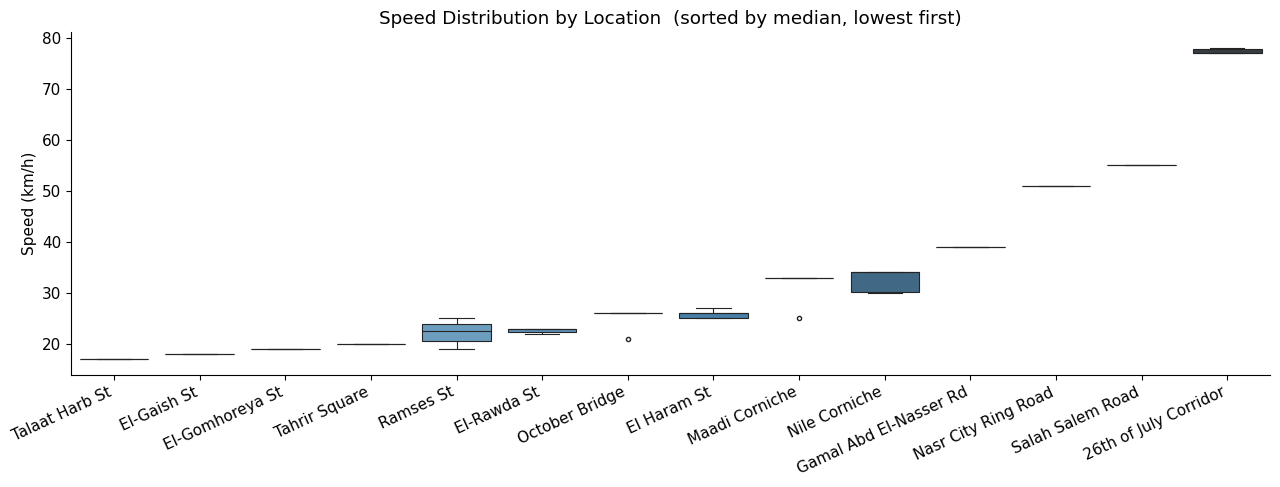

In [ ]:
# Box plot — speed distribution per location
order = df.groupby('location_name')['current_speed'].median().sort_values().index

plt.figure(figsize=(13, 5))
sns.boxplot(data=df, x='location_name', y='current_speed', order=order,
            palette='Blues_d', linewidth=0.8, fliersize=3)
plt.title('Speed Distribution by Location  (sorted by median, lowest first)')
plt.xlabel('')
plt.ylabel('Speed (km/h)')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
# Interactive Folium map
map_data = df.groupby(['location_name','requested_lat','requested_lon']).agg(
    avg_speed      = ('current_speed', 'mean'),
    avg_congestion = ('congestion_ratio', 'mean'),
    readings       = ('current_speed', 'count'),
    avg_delay_s    = ('delay_seconds', 'mean'),
    road_closures  = ('road_closure', 'sum'),
).reset_index().round(2)

m = folium.Map(
    location=[map_data['requested_lat'].mean(), map_data['requested_lon'].mean()],
    zoom_start=12, tiles='CartoDB positron')

for _, row in map_data.iterrows():
    r = row['avg_congestion']
    color = ('#2ecc71' if r >= 0.80 else '#f1c40f' if r >= 0.60
             else '#e67e22' if r >= 0.40 else '#e74c3c')
    folium.CircleMarker(
        location=[row['requested_lat'], row['requested_lon']],
        radius=22,
        color='white', weight=2,
        fill=True, fill_color=color, fill_opacity=0.85,
        popup=folium.Popup(
            f"<b>{row['location_name']}</b><br>"
            f"Avg speed: {row['avg_speed']:.1f} km/h<br>"
            f"Congestion ratio: {r:.2f}<br>"
            f"Avg delay: {row['avg_delay_s']:.0f}s<br>"
            f"Road closures: {int(row['road_closures'])}<br>"
            f"Readings: {int(row['readings'])}",
            max_width=220),
        tooltip=f"{row['location_name']} — ratio: {r:.2f}"
    ).add_to(m)

legend_html = '''
<div style="position:fixed;bottom:30px;left:30px;z-index:999;
     background:white;padding:12px 16px;border-radius:8px;
     font-size:13px;border:1px solid #ccc;box-shadow:2px 2px 8px rgba(0,0,0,.2)">
<b>Congestion level</b><br>
<span style="color:#2ecc71">●</span> Free Flow  (ratio ≥ 0.80)<br>
<span style="color:#f1c40f">●</span> Light      (0.60 – 0.80)<br>
<span style="color:#e67e22">●</span> Moderate   (0.40 – 0.60)<br>
<span style="color:#e74c3c">●</span> Heavy      (< 0.40)<br>
<small>Click a circle for details</small>
</div>'''
m.get_root().html.add_child(folium.Element(legend_html))

print('🗺️  Interactive map — click any circle for full stats:')
m

🗺️  Interactive map — click any circle for full stats:


## 11. Road Closure & Confidence Analysis

Total road closures: 30 out of 140 readings (21.4%)


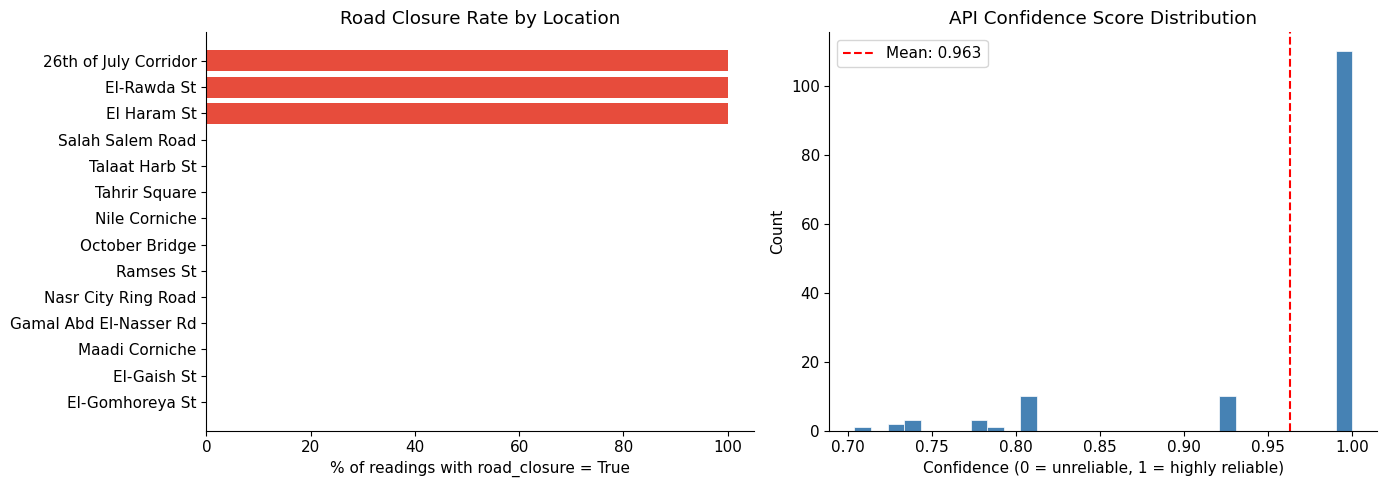


Low confidence readings (< 0.5): 0 (0.0%)


In [ ]:
closures = df['road_closure'].sum()
print(f'Total road closures: {closures} out of {len(df)} readings ({closures/len(df)*100:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Closures by location
closure_by_loc = df.groupby('location_name')['road_closure'].agg(['sum','count'])
closure_by_loc['pct'] = (closure_by_loc['sum'] / closure_by_loc['count'] * 100).round(1)
closure_by_loc = closure_by_loc.sort_values('pct', ascending=True)
colors = ['#e74c3c' if v > 0 else 'steelblue' for v in closure_by_loc['sum']]
axes[0].barh(closure_by_loc.index, closure_by_loc['pct'], color=colors)
axes[0].set_title('Road Closure Rate by Location')
axes[0].set_xlabel('% of readings with road_closure = True')

# Confidence distribution
axes[1].hist(df['confidence'].dropna(), bins=30, color='steelblue',
             edgecolor='white', linewidth=0.5)
axes[1].axvline(df['confidence'].mean(), color='red', linestyle='--', linewidth=1.5,
                label=f'Mean: {df["confidence"].mean():.3f}')
axes[1].set_title('API Confidence Score Distribution')
axes[1].set_xlabel('Confidence (0 = unreliable, 1 = highly reliable)')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

# Low confidence readings
low_conf = df[df['confidence'] < 0.5]
print(f'\nLow confidence readings (< 0.5): {len(low_conf)} ({len(low_conf)/len(df)*100:.1f}%)')
if len(low_conf) > 0:
    print('  These should be flagged in the pipeline — less reliable data!')
    print(low_conf[['location_name','request_time','current_speed','confidence']].head(10).to_string(index=False))

## 12. Correlation & Feature Relationships

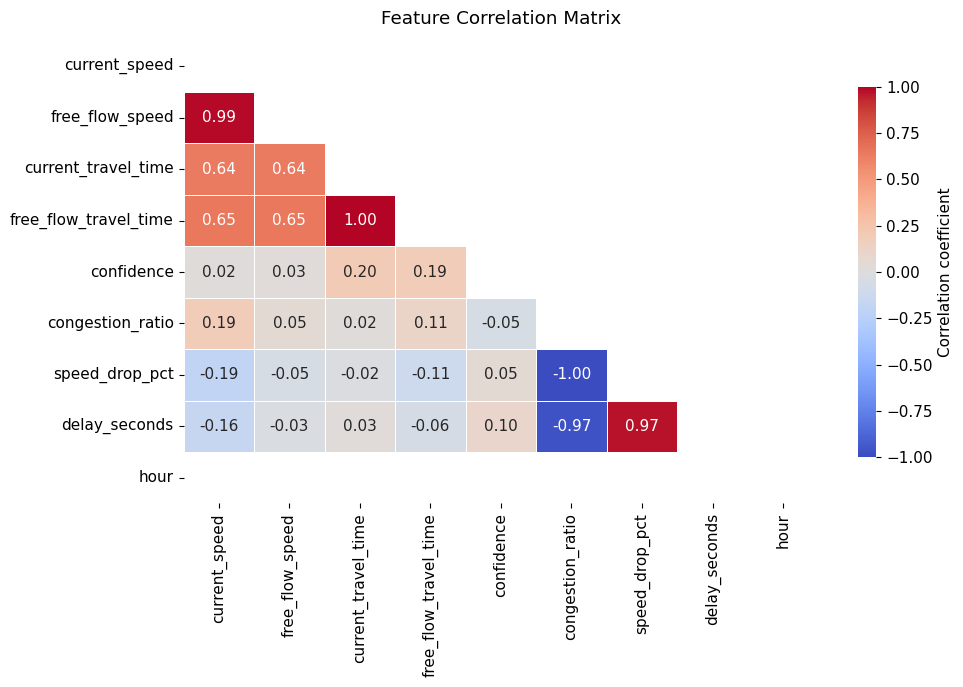

Top correlations with current_speed:
free_flow_speed          0.99
free_flow_travel_time    0.65
current_travel_time      0.64
congestion_ratio         0.19
confidence               0.02
delay_seconds           -0.16
speed_drop_pct          -0.19
hour                      NaN


In [ ]:
num_cols = ['current_speed','free_flow_speed','current_travel_time',
            'free_flow_travel_time','confidence','congestion_ratio',
            'speed_drop_pct','delay_seconds','hour']
corr = df[num_cols].corr().round(2)

plt.figure(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, vmin=-1, vmax=1, linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': 'Correlation coefficient'})
plt.title('Feature Correlation Matrix', pad=12)
plt.tight_layout()
plt.show()

print('Top correlations with current_speed:')
print(corr['current_speed'].drop('current_speed').sort_values(ascending=False).round(3).to_string())

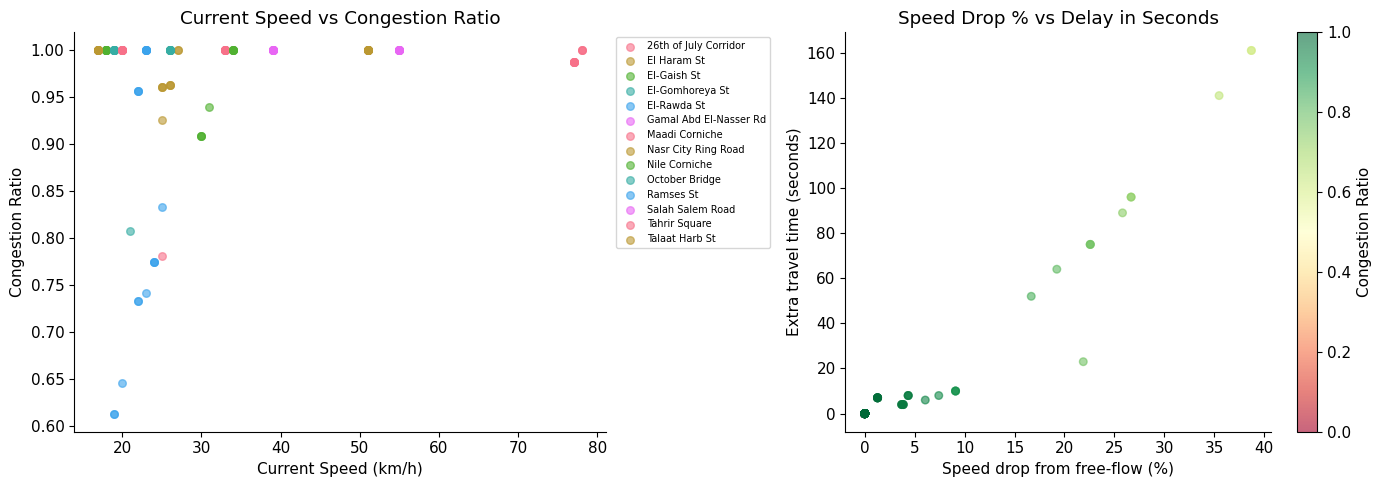

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: current_speed vs congestion_ratio coloured by location
for loc, grp in df.groupby('location_name'):
    axes[0].scatter(grp['current_speed'], grp['congestion_ratio'],
                    alpha=0.6, s=30, label=loc)
axes[0].set_title('Current Speed vs Congestion Ratio')
axes[0].set_xlabel('Current Speed (km/h)')
axes[0].set_ylabel('Congestion Ratio')
axes[0].legend(fontsize=7, bbox_to_anchor=(1.01, 1), loc='upper left')

# Delay vs speed drop %
sc = axes[1].scatter(df['speed_drop_pct'], df['delay_seconds'],
                     c=df['congestion_ratio'], cmap='RdYlGn',
                     vmin=0, vmax=1, alpha=0.6, s=30)
plt.colorbar(sc, ax=axes[1], label='Congestion Ratio')
axes[1].set_title('Speed Drop % vs Delay in Seconds')
axes[1].set_xlabel('Speed drop from free-flow (%)')
axes[1].set_ylabel('Extra travel time (seconds)')

plt.tight_layout()
plt.show()

## 13. Key Findings

In [ ]:
worst_loc     = loc_summary['avg_congestion'].idxmin()
best_loc      = loc_summary['avg_congestion'].idxmax()
heavy_pct     = df['congestion_level'].isin(['Heavy','Severe']).mean() * 100
low_conf_pct  = (df['confidence'] < 0.5).mean() * 100
avg_delay     = df['delay_seconds'].mean()

print('═' * 65)
print('   KEY FINDINGS FROM REAL TOMTOM DATA')
print('═' * 65)
print(f'''
 Dataset
   • {len(df):,} real readings from TomTom API
   • {df['location_name'].nunique()} locations monitored
   • Time span: {df['request_time'].min().strftime("%Y-%m-%d %H:%M")} →
                {df['request_time'].max().strftime("%Y-%m-%d %H:%M")}
   • FRC types seen: {sorted(df['frc'].dropna().unique())}

 Speed
   • Average current speed   : {df['current_speed'].mean():.1f} km/h
   • Average free-flow speed : {df['free_flow_speed'].mean():.1f} km/h
   • Avg speed lost to traffic: {(df['free_flow_speed'] - df['current_speed']).mean():.1f} km/h
   • Average extra delay      : {avg_delay:.0f} seconds per reading

 Congestion
   • {heavy_pct:.1f}% of readings: Heavy or Severe congestion
   • Most congested location  : {worst_loc}
     (avg ratio: {loc_summary.loc[worst_loc, "avg_congestion"]:.2f})
   • Least congested location : {best_loc}
     (avg ratio: {loc_summary.loc[best_loc, "avg_congestion"]:.2f})

 Road Closures & Data Quality
   • Road closures detected   : {int(closures)}
   • Low confidence readings  : {low_conf_pct:.1f}%  (confidence < 0.5)
   • Missing values in speed  : {df['current_speed'].isna().mean()*100:.1f}%
''')

═════════════════════════════════════════════════════════════════
   KEY FINDINGS FROM REAL TOMTOM DATA
═════════════════════════════════════════════════════════════════

 Dataset
   • 140 real readings from TomTom API
   • 14 locations monitored
   • Time span: 2026-03-24 11:42 →
                2026-03-24 11:53
   • FRC types seen: ['FRC0', 'FRC1', 'FRC2', 'FRC3', 'FRC4']

 Speed
   • Average current speed   : 32.7 km/h
   • Average free-flow speed : 33.6 km/h
   • Avg speed lost to traffic: 0.9 km/h
   • Average extra delay      : 9 seconds per reading

 Congestion
   • 0.0% of readings: Heavy or Severe congestion
   • Most congested location  : Ramses St
     (avg ratio: 0.72)
   • Least congested location : El-Gaish St
     (avg ratio: 1.00)

 Road Closures & Data Quality
   • Road closures detected   : 30
   • Low confidence readings  : 0.0%  (confidence < 0.5)
   • Missing values in speed  : 0.0%

